In [49]:
%matplotlib inline
from __future__ import division
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt
from numba import jit
import os
from tqdm import tqdm

In [50]:
#----------------------------------------------------------------------
##  BLOCK OF FUNCTIONS USED IN THE MAIN CODE
#----------------------------------------------------------------------

def initialstate(N, mode='random'):
    """
    Generate a spin configuration as angles in [0, 2pi).
    mode='random'  -> disordered start (high-T phase)
    mode='ordered' -> all spins aligned (low-T phase)
    """
    if mode == 'random':
        return np.random.uniform(0, 2*np.pi, (N, N))
    else:  # ordered
        return np.zeros((N, N), dtype=np.float64)


@jit(nopython=True)
def wrap_angle(d):
    """Wrap an angle difference into [-pi, pi]."""
    return (d + np.pi) % (2 * np.pi) - np.pi


@jit(nopython=True)
def mcmove(spins, beta, J, N, delta):
    """
    One full Monte Carlo sweep (N*N single-spin Metropolis updates).

    Each trial move perturbs a randomly chosen spin angle by a uniform
    random amount in [-delta, delta].  delta is typically tuned so that
    the acceptance rate sits near 50%.
    """
    accepted = 0
    for _ in range(N * N):
        i = np.random.randint(0, N)
        j = np.random.randint(0, N)

        old_angle = spins[i, j]
        new_angle = old_angle + np.random.uniform(-delta, delta)

        # Local energy change: only the four nearest-neighbor bonds change.
        # H = -J sum_{<ij>} cos(theta_i - theta_j)
        nb_old = (np.cos(spins[(i+1) % N, j]         - old_angle) +
                  np.cos(spins[(i-1) % N, j]         - old_angle) +
                  np.cos(spins[i,         (j+1) % N] - old_angle) +
                  np.cos(spins[i,         (j-1) % N] - old_angle))

        nb_new = (np.cos(spins[(i+1) % N, j]         - new_angle) +
                  np.cos(spins[(i-1) % N, j]         - new_angle) +
                  np.cos(spins[i,         (j+1) % N] - new_angle) +
                  np.cos(spins[i,         (j-1) % N] - new_angle))

        dE = -J * (nb_new - nb_old)

        if dE < 0 or rand() < np.exp(-beta * dE):
            spins[i, j] = new_angle % (2 * np.pi)
            accepted += 1

    return spins, accepted / (N * N)


@jit(nopython=True)
def calcEnergy(spins, J, N):
    """
    Total energy of the configuration.
    Counts each bond once (rightward + downward neighbors only).
    """
    energy = 0.0
    for i in range(N):
        for j in range(N):
            energy += -J * (np.cos(spins[i, j] - spins[(i+1) % N, j]) +
                            np.cos(spins[i, j] - spins[i, (j+1) % N]))
    return energy


@jit(nopython=True)
def calcMag(spins):
    """
    XY order parameter: magnitude of the mean spin vector.
    m = |<e^{i*theta}>| = sqrt(<cos>^2 + <sin>^2)
    Ranges from 0 (disordered) to 1 (fully ordered).
    """
    N2 = spins.shape[0] * spins.shape[1]
    mx = 0.0
    my = 0.0
    for i in range(spins.shape[0]):
        for j in range(spins.shape[1]):
            mx += np.cos(spins[i, j])
            my += np.sin(spins[i, j])
    return np.sqrt((mx / N2)**2 + (my / N2)**2)


@jit(nopython=True)
def calcHelicity(spins, J, N, beta):
    """
    Helicity modulus (superfluid stiffness) Upsilon.

    This is the key observable for the BKT transition.  It measures the
    free-energy cost of a global twist in the order parameter:

        Upsilon = (J/N^2) * [ <sum cos(Delta_x theta)>
                             - beta * <(sum sin(Delta_x theta))^2> ]

    Below T_BKT: Upsilon > 0  (quasi-long-range order, bound vortex pairs)
    Above T_BKT: Upsilon -> 0 (disordered, free vortices)

    At T_BKT the universal jump condition gives  Upsilon = 2 T_BKT / pi.
    """
    cos_sum = 0.0
    sin_sum = 0.0
    for i in range(N):
        for j in range(N):
            dtheta = spins[(i+1) % N, j] - spins[i, j]
            cos_sum += np.cos(dtheta)
            sin_sum += np.sin(dtheta)
    return J * (cos_sum - beta * sin_sum**2) / (N * N)


@jit(nopython=True)
def detectVortices(spins, N):
    """
    Detect topological defects (vortices / antivortices) on the dual lattice.

    For each plaquette the winding number is computed by summing the
    angle differences (each wrapped to [-pi, pi]) around its four edges.
    A result of +1 is a vortex, -1 is an antivortex.

    Returns an (N, N) integer array of winding numbers.
    """
    vmap = np.zeros((N, N), dtype=np.int32)
    for i in range(N):
        for j in range(N):
            ip = (i + 1) % N
            jp = (j + 1) % N
            d1 = wrap_angle(spins[ip, j]  - spins[i,  j])
            d2 = wrap_angle(spins[ip, jp] - spins[ip, j])
            d3 = wrap_angle(spins[i,  jp] - spins[ip, jp])
            d4 = wrap_angle(spins[i,  j]  - spins[i,  jp])
            circ = d1 + d2 + d3 + d4
            vmap[i, j] = int(round(circ / (2 * np.pi)))
    return vmap

In [51]:
#----------------------------------------------------------------------
##  VISUALIZATION AND I/O HELPERS
#----------------------------------------------------------------------

def plotSpins(spins, N, T, folder=None):
    """
    Quiver plot of the spin field.  Each arrow points in the direction
    given by the spin angle theta_{ij}.
    Color encodes the angle for easy visual inspection of vortices.
    """
    X, Y = np.meshgrid(np.arange(N), np.arange(N))
    U = np.cos(spins)
    V = np.sin(spins)

    fig, ax = plt.subplots(figsize=(6, 6))
    q = ax.quiver(X, Y, U, V, spins % (2 * np.pi),
                  cmap='hsv', clim=(0, 2 * np.pi),
                  pivot='mid', headwidth=3, headlength=4, scale=N * 1.4)
    plt.colorbar(q, ax=ax, label='Angle (rad)')
    ax.set_title(f'XY spins   T = {T:.3f}   N = {N}', fontsize=13)
    ax.set_xlim(-0.5, N - 0.5)
    ax.set_ylim(-0.5, N - 0.5)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout()

    if folder is not None:
        os.makedirs(folder, exist_ok=True)
        plt.savefig(os.path.join(folder, f'spins_T{T:.3f}.png'), dpi=120)
    plt.show()
    plt.close()


def plotVortices(spins, N, T, folder=None):
    """
    Show vortex (+1) and antivortex (-1) locations overlaid on a
    grayscale image of the spin angle.
    """
    vmap = detectVortices(spins, N)
    vortex_pos     = np.argwhere(vmap ==  1)
    antivortex_pos = np.argwhere(vmap == -1)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(spins.T, origin='lower', cmap='twilight',
              vmin=0, vmax=2 * np.pi, interpolation='nearest')
    if len(vortex_pos):
        ax.scatter(vortex_pos[:, 0], vortex_pos[:, 1],
                   c='red',  s=80, marker='+', linewidths=2, label='Vortex')
    if len(antivortex_pos):
        ax.scatter(antivortex_pos[:, 0], antivortex_pos[:, 1],
                   c='blue', s=80, marker='x', linewidths=2, label='Antivortex')
    ax.set_title(f'Vortices   T = {T:.3f}   N = {N}   '
                 f'n_v = {len(vortex_pos)}, n_av = {len(antivortex_pos)}', fontsize=12)
    ax.legend(loc='upper right', fontsize=10)
    ax.axis('off')
    plt.tight_layout()

    if folder is not None:
        os.makedirs(folder, exist_ok=True)
        plt.savefig(os.path.join(folder, f'vortices_T{T:.3f}.png'), dpi=120)
    plt.show()
    plt.close()


def saveFigAndData(spins, N, T, folder):
    """
    Save the spin configuration (txt) and spin-field figure (png).
    Follows the same convention as the Ising notebook.
    """
    os.makedirs(folder, exist_ok=True)
    fname = f'T_{T:.4f}'
    np.savetxt(os.path.join(folder, fname + '.txt'), spins)
    plotSpins(spins, N, T, folder=folder)

In [52]:
#----------------------------------------------------------------------
##  SIMULATION PARAMETERS
#----------------------------------------------------------------------

nt       = 20          # number of temperature points
N_vals   = [20]        # lattice sizes to simulate
eqSteps  = 10000       # MC sweeps for equilibration (thermalisation)
mcSteps  = 50000       # MC sweeps for measurement
J        = 1.0         # coupling constant (ferromagnetic)
delta    = np.pi       # max angle perturbation per Metropolis trial

# Temperature range bracketing the BKT transition.
# For J=1, k_B=1 the BKT temperature is T_BKT ~ 0.893.
# The universal jump condition gives Upsilon(T_BKT^-) = 2*T_BKT/pi ~ 0.569.
T_vals   = np.linspace(0.2, 2.0, nt)
beta_vals = 1 / T_vals
T_BKT    = 0.8816   # theoretical value (marked on plots)

folder_root = 'xy_model'

In [53]:
# Warm up numba JIT compilation with a tiny run (avoids timing the compile
# on the first real temperature point).
_s = initialstate(4)
_s, _ = mcmove(_s, 1.0, 1.0, 4, np.pi)
_ = calcEnergy(_s, 1.0, 4)
_ = calcMag(_s)
_ = calcHelicity(_s, 1.0, 4, 1.0)
_ = detectVortices(_s, 4)
print('JIT warm-up complete.')

JIT warm-up complete.


In [54]:
#----------------------------------------------------------------------
##  MAIN SIMULATION LOOP
#----------------------------------------------------------------------

results = {}   # keyed by N

for N in N_vals:
    folder = os.path.join(folder_root, f'data_N_{N}')
    os.makedirs(folder, exist_ok=True)

    n1  = 1.0 / mcSteps
    n2  = 1.0 / (mcSteps * mcSteps)
    Ns  = N * N

    E_arr  = np.zeros(nt)
    M_arr  = np.zeros(nt)
    C_arr  = np.zeros(nt)
    X_arr  = np.zeros(nt)
    Y_arr  = np.zeros(nt)   # helicity modulus
    NV_arr = np.zeros(nt)   # mean vortex + antivortex density

    print(f'\n=== N = {N} ===')
    for tt in tqdm(range(nt)):
        T    = T_vals[tt]
        beta = 1.0 / T
        fname = os.path.join(folder, f'beta_{beta:.4f}.txt')

        # Load saved config if it exists, otherwise start fresh
        if os.path.isfile(fname):
            config = np.loadtxt(fname)
        else:
            config = initialstate(N)

        # --- Equilibration ---
        for _ in range(eqSteps):
            config, _ = mcmove(config, beta, J, N, delta)

        # --- Measurement ---
        E1 = E2 = M1 = M2 = Y1 = NV1 = 0.0
        for _ in range(mcSteps):
            config, _ = mcmove(config, beta, J, N, delta)

            Ene  = calcEnergy(config, J, N) / Ns
            Mag  = calcMag(config)
            Ups  = calcHelicity(config, J, N, beta)
            vmap = detectVortices(config, N)
            nv   = np.sum(np.abs(vmap)) / Ns   # total defect density

            E1  += Ene
            E2  += Ene * Ene
            M1  += Mag
            M2  += Mag * Mag
            Y1  += Ups
            NV1 += nv

        E_arr[tt]  = n1 * E1
        M_arr[tt]  = n1 * M1
        C_arr[tt]  = (n1 * E2 - n2 * E1 * E1) * beta**2 * Ns
        X_arr[tt]  = (n1 * M2 - n2 * M1 * M1) * beta * Ns
        Y_arr[tt]  = n1 * Y1
        NV_arr[tt] = n1 * NV1

        np.savetxt(fname, config)   # save final config

    results[N] = dict(E=E_arr, M=M_arr, C=C_arr, X=X_arr, Y=Y_arr, NV=NV_arr)

print('\nSimulation complete.')


=== N = 20 ===


100%|██████████| 20/20 [01:23<00:00,  4.19s/it]


Simulation complete.


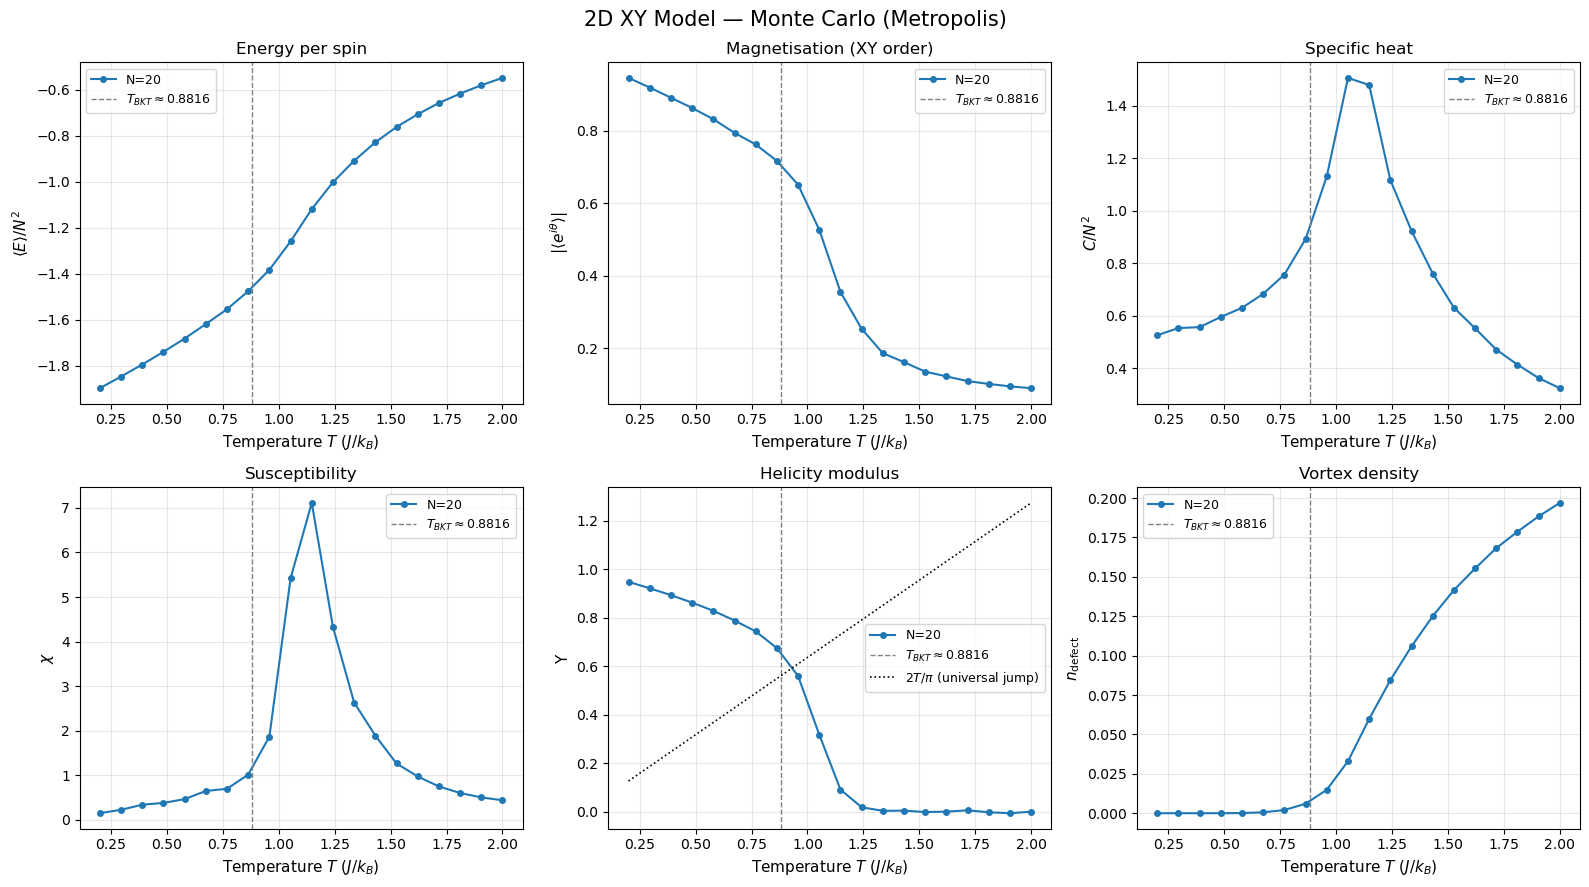

In [55]:
#----------------------------------------------------------------------
##  PLOT THERMODYNAMIC OBSERVABLES
#----------------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('2D XY Model — Monte Carlo (Metropolis)', fontsize=15)

labels = {
    'E' : ('Energy per spin',          r'$\langle E \rangle / N^2$'),
    'M' : ('Magnetisation (XY order)', r'$|\langle e^{i\theta} \rangle|$'),
    'C' : ('Specific heat',            r'$C / N^2$'),
    'X' : ('Susceptibility',           r'$\chi$'),
    'Y' : ('Helicity modulus',         r'$\Upsilon$'),
    'NV': ('Vortex density',           r'$n_{\rm defect}$'),
}

keys = ['E', 'M', 'C', 'X', 'Y', 'NV']
for ax, key in zip(axes.flat, keys):
    title, ylabel = labels[key]
    for N, res in results.items():
        ax.plot(T_vals, res[key], 'o-', ms=4, label=f'N={N}')

    # BKT temperature marker
    ax.axvline(T_BKT, color='gray', linestyle='--', linewidth=1, label=rf'$T_{{BKT}}\approx{T_BKT}$')

    # Universal jump line on helicity plot
    if key == 'Y':
        ax.plot(T_vals, 2 * T_vals / np.pi, 'k:', linewidth=1.2,
                label=r'$2T/\pi$ (universal jump)')

    ax.set_xlabel('Temperature $T$ ($J/k_B$)', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('figures/xy_model', exist_ok=True)
plt.savefig('figures/xy_model/observables.png', dpi=150)
plt.show()


--- T = 0.3895 ---


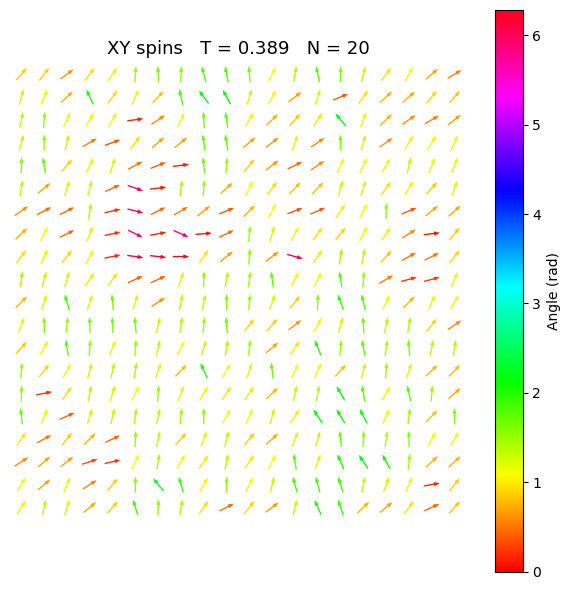

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


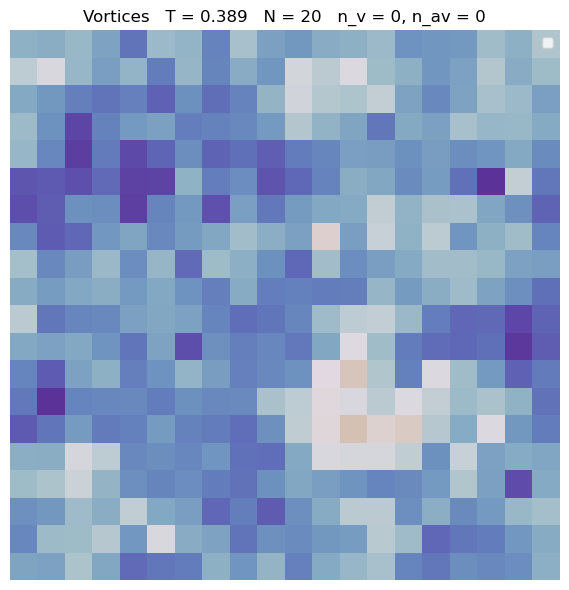


--- T = 0.8632 ---


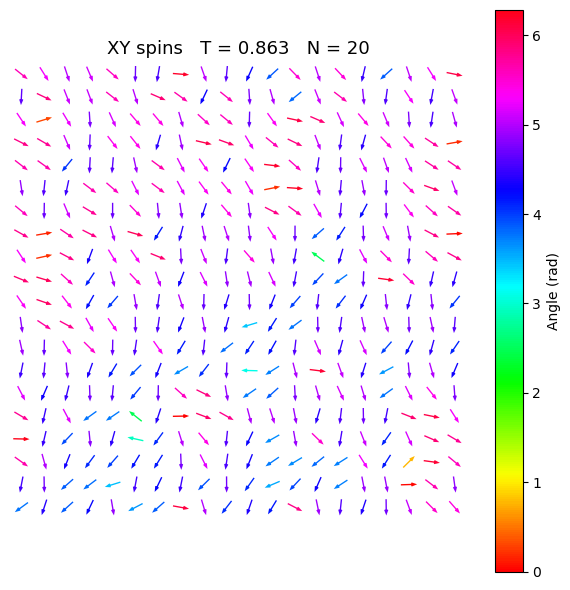

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


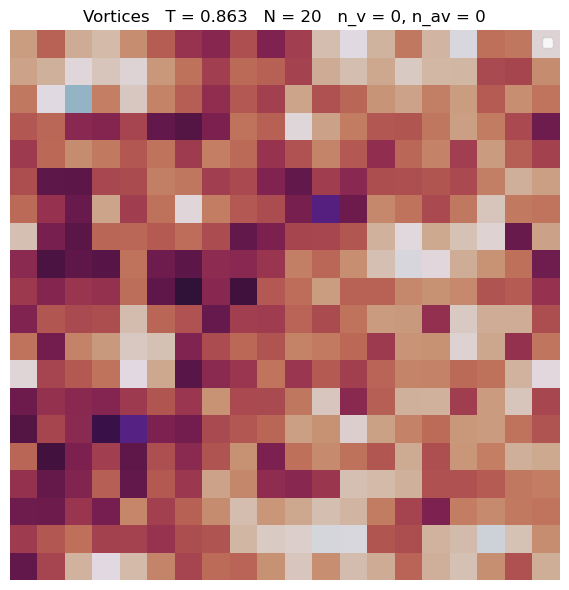


--- T = 1.5263 ---


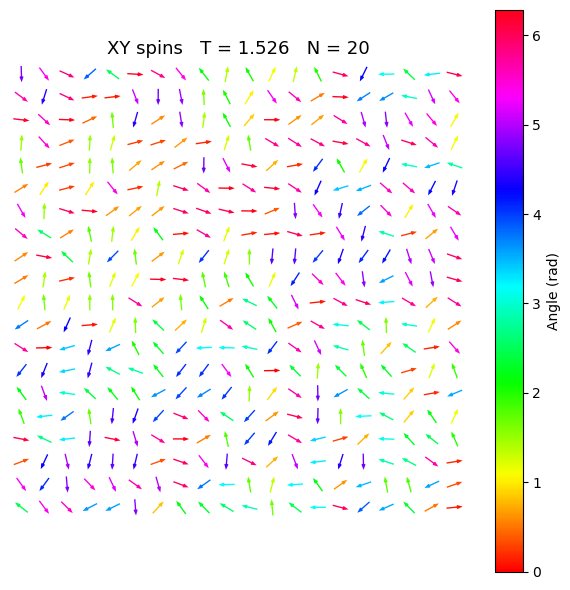

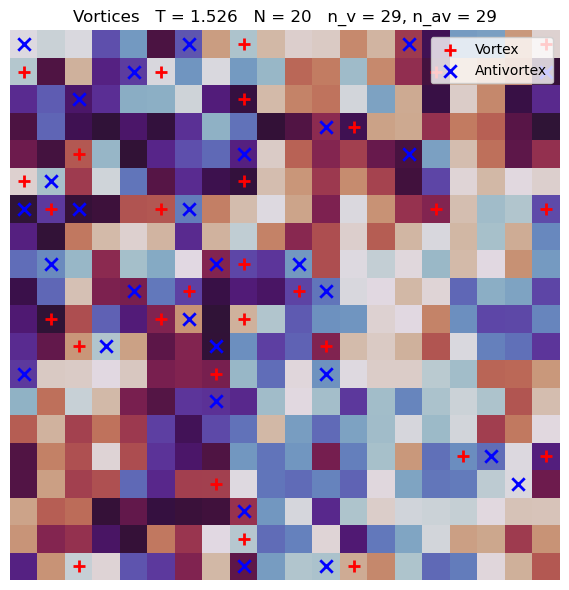

In [56]:
#----------------------------------------------------------------------
##  VISUALIZE SPIN CONFIGURATIONS AT THREE TEMPERATURES
#----------------------------------------------------------------------

# Pick one lattice size to visualize
N_vis   = N_vals[0]
T_show  = [0.4, T_BKT, 1.5]   # low / critical / high

for T_target in T_show:
    tt      = np.argmin(np.abs(T_vals - T_target))
    T_actual = T_vals[tt]
    beta_actual = beta_vals[tt]
    fname   = os.path.join(folder_root, f'data_N_{N_vis}', f'beta_{beta_actual:.4f}.txt')
    config  = np.loadtxt(fname)
    print(f'\n--- T = {T_actual:.4f} ---')
    plotSpins(config, N_vis, T_actual)
    plotVortices(config, N_vis, T_actual)

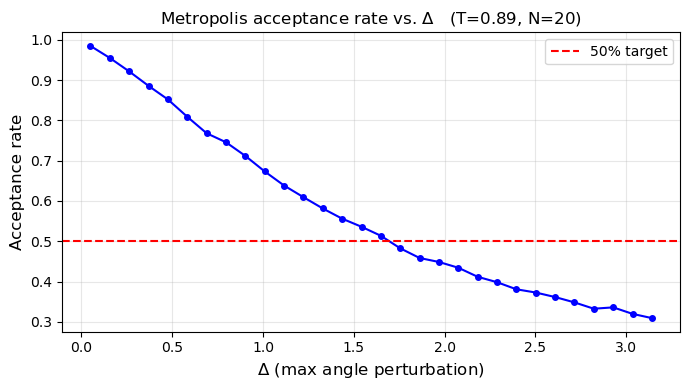

Delta giving ~50% acceptance: 1.649 rad


In [57]:
#----------------------------------------------------------------------
##  ACCEPTANCE RATE TUNING DEMO
##  Run this cell to find the optimal delta for a given temperature.
#----------------------------------------------------------------------

T_tune   = 0.89          # temperature to tune at
beta_tune = 1.0 / T_tune
N_tune   = N_vals[0]
n_sweeps = 200
deltas   = np.linspace(0.05, np.pi, 30)
acc_rates = []

for d in deltas:
    s   = initialstate(N_tune)
    acc = 0.0
    for _ in range(n_sweeps):
        s, a = mcmove(s, beta_tune, J, N_tune, d)
        acc += a
    acc_rates.append(acc / n_sweeps)

plt.figure(figsize=(7, 4))
plt.plot(deltas, acc_rates, 'b-o', ms=4)
plt.axhline(0.5, color='r', linestyle='--', label='50% target')
plt.xlabel(r'$\Delta$ (max angle perturbation)', fontsize=12)
plt.ylabel('Acceptance rate', fontsize=12)
plt.title(f'Metropolis acceptance rate vs. $\Delta$   (T={T_tune}, N={N_tune})', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_delta = deltas[np.argmin(np.abs(np.array(acc_rates) - 0.5))]
print(f'Delta giving ~50% acceptance: {best_delta:.3f} rad')

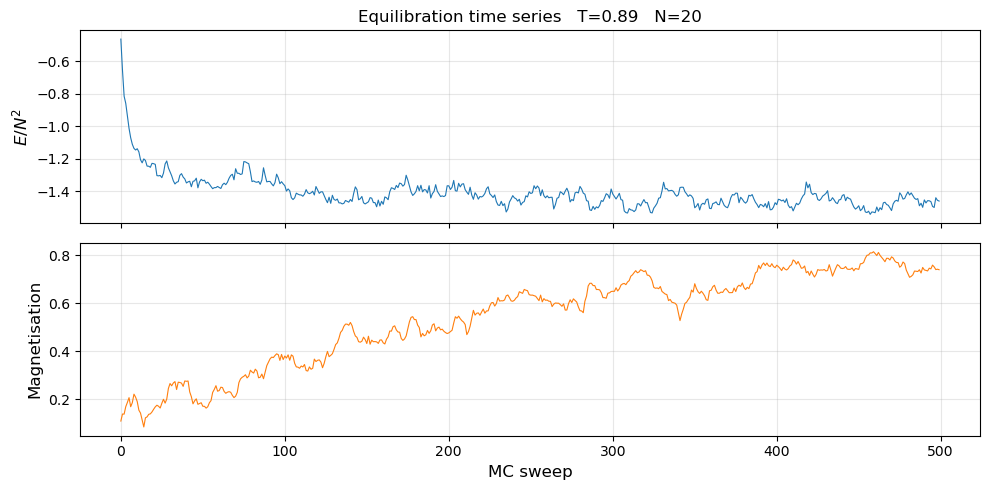

In [58]:
#----------------------------------------------------------------------
##  EQUILIBRATION CHECK — ENERGY TIME SERIES
#----------------------------------------------------------------------

T_check  = 0.89
N_check  = N_vals[0]
n_record = 500
beta_chk = 1.0 / T_check

config_chk = initialstate(N_check, mode='random')
energy_ts  = np.zeros(n_record)
mag_ts     = np.zeros(n_record)

for step in range(n_record):
    config_chk, _ = mcmove(config_chk, beta_chk, J, N_check, delta)
    energy_ts[step] = calcEnergy(config_chk, J, N_check) / (N_check**2)
    mag_ts[step]    = calcMag(config_chk)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax1.plot(energy_ts, lw=0.8)
ax1.set_ylabel(r'$E/N^2$', fontsize=12)
ax1.set_title(f'Equilibration time series   T={T_check}   N={N_check}', fontsize=12)
ax1.grid(alpha=0.3)

ax2.plot(mag_ts, color='C1', lw=0.8)
ax2.set_ylabel('Magnetisation', fontsize=12)
ax2.set_xlabel('MC sweep', fontsize=12)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/xy_model/equilibration.png', dpi=120)
plt.show()